In [40]:
import torch


# a simple function, we interested in defferentiating the func y = 2x^t*x

In [41]:
x = torch.arange(4.0)
x

tensor([0., 1., 2., 3.])

In [42]:
# require_grad, it told pytorch to build computational graph, that track every calculation start from x

x.requires_grad_(True) # or 
# x = torch.arange(4.0, requires_grad=True)
print(x.grad) # this is None by default


None


In [43]:
y = 2 * torch.dot(x, x)
y

tensor(28., grad_fn=<MulBackward0>)

In [44]:
# take the gradient of y with respect to x
y.backward()
print(x.grad)

tensor([ 0.,  4.,  8., 12.])


In [45]:
# test if x.grad equal to 4*x
x.grad == 4*x

tensor([True, True, True, True])

In [46]:
y = x.sum()
print(y)
y.backward()
print(x.grad)

tensor(6., grad_fn=<SumBackward0>)
tensor([ 1.,  5.,  9., 13.])


In [49]:
# the grad does not reset, we need to reset it 
x.grad.zero_() # _ mean do it in place 
y = x.sum()
y.backward()
print(x.grad)

tensor([1., 1., 1., 1.])


# Non-Scalar

In [50]:
# in computer, compute a jacobian matrix is waste a lot of memory so we process this 
# we compress it into a vector or an scalar like this 
x.grad.zero_()
y = x*x
y.backward(gradient=torch.ones(len(y)))
x.grad

tensor([0., 2., 4., 6.])

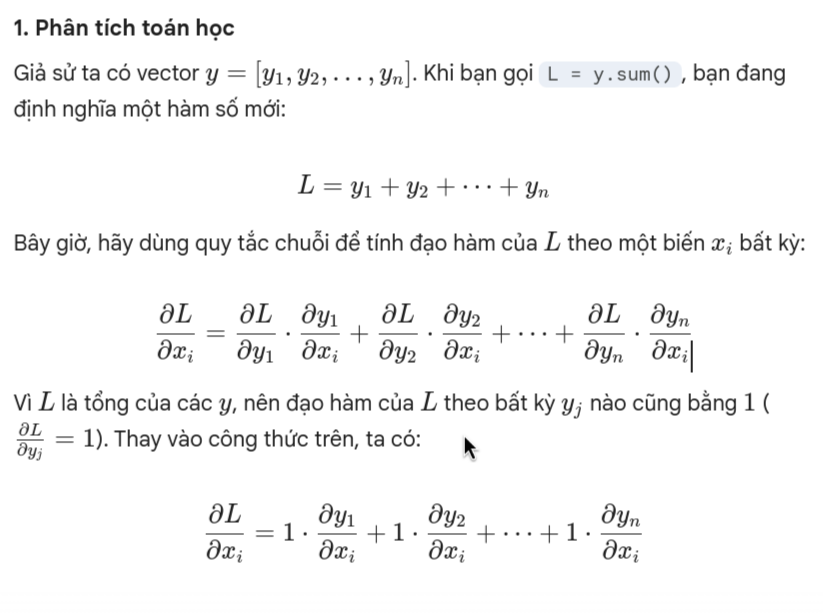

In [55]:
# faster way using sum, it equivalent
x.grad.zero_()
y = x*x
print(y)
print(y.sum())
y.sum().backward()
print(y)
x.grad

tensor([0., 1., 4., 9.], grad_fn=<MulBackward0>)
tensor(14., grad_fn=<SumBackward0>)
tensor([0., 1., 4., 9.], grad_fn=<MulBackward0>)


tensor([0., 2., 4., 6.])

# detaching computation 

In [ ]:
# sometime, we just care about some f but don't care about the middle function 
# set up problem 
"""
we have y = x*x 
z = y * x 

normal: z' = 3x**2 
but we don't care y, we just care about how much x DIRECTLY impact on z 
we detach y out of computational graph, 
"""

x.grad.zero_()
y = x * x 
u = y.detach()
z = u * x 

z.sum().backward()
x.grad == u # because u is constance right now, so x will be 1 

# note, the computational graph of y still there 
# the detach only create new branch and z work on that branch, it not work on branch that have y



tensor([True, True, True, True])

# Gradient and python control flow

In [58]:
def f(a):
    b = a * 2
    while b.norm() < 1000:
        b = b * 2
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b
    return c


a = torch.randn(size=(), requires_grad=True)
d = f(a)
d.backward()

print(a.grad)

a.grad == d/a

tensor(1024.)


tensor(True)

# Exercise

In [ ]:
# what if we run backward() twice 
# runtime error, because pytorch auto delete the computational graph after calling backward
# if want to retain that 
# use this 
y.backward(retain_graph=True)

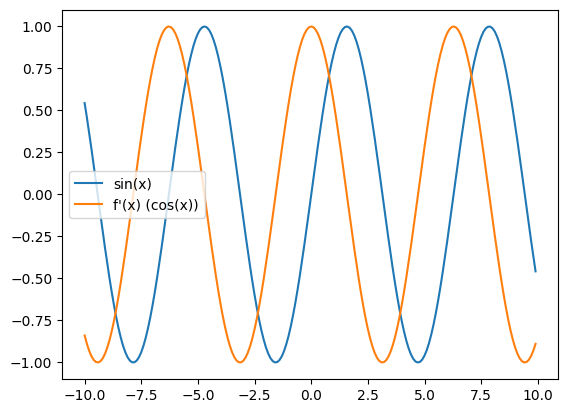

tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, Tr

In [63]:
# draw the f(x) = sin(x) and there derivative
import matplotlib.pyplot as plt 
x = torch.arange(-10,10,0.1, requires_grad=True)
y = torch.sin(x)
y.sum().backward() # force it to scalar
# print(x)
# print(y)
# print(x.grad)

# we need to detach that out of computational graph, to convert it to numpy to work with matplotlib

plt.plot(x.detach(), y.detach(), label="sin(x)") # plt auto call .numpy() for each variable
# y' = x.grad = cos(x)
plt.plot(x.detach(), x.grad, label='f\'(x) (cos(x))')
plt.legend()
plt.show()

print(x.grad == torch.cos(x))
